📊 Đã thu thập thành công 111 điểm dữ liệu loss từ step 0 đến 210.
🎉 Xuất sắc! Biểu đồ hoàn chỉnh đã được lưu tại thư mục dự án với tên: value_model_loss_perfect.png


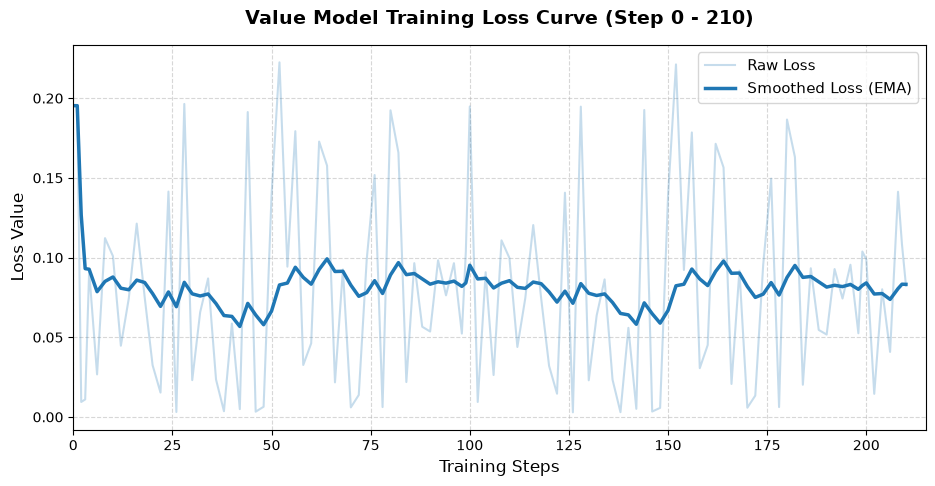

In [3]:
import re
import matplotlib.pyplot as plt
import pandas as pd

# 1. Khai báo đường dẫn đến file log của 3 chặng (Bạn kiểm tra tên file chính xác là output.log nhé)
log_paths = [
    r"C:\TONGHOPTRENLOP\HK6\ML\Project\RISE\policy_and_value\policy_offline_and_value\wandb\offline-run-20260626_222334-3ksez41m\files\output.log",
    r"C:\TONGHOPTRENLOP\HK6\ML\Project\RISE\policy_and_value\policy_offline_and_value\wandb\offline-run-20260627_022802-3ksez41m\files\output.log",
    r"C:\TONGHOPTRENLOP\HK6\ML\Project\RISE\policy_and_value\policy_offline_and_value\wandb\offline-run-20260627_094931-3ksez41m\files\output.log"
]

data_dict = {}

# 2. Quét qua từng file để trích xuất dữ liệu toán học
for path in log_paths:
    try:
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                # Tìm định dạng gập trong Terminal: step=X loss=Y hoặc loss=Y ... step=X
                match = re.search(r"step=(\d+).*?loss=([0-9.]+)", line) or re.search(r"loss=([0-9.]+).*?step=(\d+)", line)
                if match:
                    # Đảm bảo lấy đúng thứ tự group dựa trên regex match
                    if "step=" in match.group(0) and match.group(0).index("step=") < match.group(0).index("loss="):
                        step_val = int(match.group(1))
                        loss_val = float(match.group(2))
                    else:
                        loss_val = float(match.group(1))
                        step_val = int(match.group(2))
                    
                    # Nếu trùng step, chặng sau (đã resume) sẽ ghi đè chặng trước bị lỗi
                    data_dict[step_val] = loss_val
    except FileNotFoundError:
        print(f"⚠️ Không tìm thấy file tại đường dẫn: {path}. Bạn kiểm tra lại tên file có phải output.log không nhé.")

if not data_dict:
    print("❌ Thất bại: Không trích xuất được điểm dữ liệu loss nào. Hãy chắc chắn các file log có chứa text dạng 'step=...'")
    exit()

# 3. Sắp xếp dữ liệu theo thứ tự step tăng dần
sorted_steps = sorted(data_dict.keys())
sorted_losses = [data_dict[s] for s in sorted_steps]

print(f"📊 Đã thu thập thành công {len(sorted_steps)} điểm dữ liệu loss từ step {sorted_steps[0]} đến {sorted_steps[-1]}.")

# 4. Tiến hành vẽ biểu đồ khoa học
plt.figure(figsize=(11, 5))

# Vẽ đường thô răng cưa (màu nhạt) do batch_size=1
plt.plot(sorted_steps, sorted_losses, alpha=0.25, color='#1f77b4', label='Raw Loss')

# Áp dụng bộ lọc Smoothing (EMA) giống thanh gạt 0.9 của W&B để lộ đường cong hội tụ
smoothed_losses = pd.Series(sorted_losses).ewm(alpha=0.1).mean()
plt.plot(sorted_steps, smoothed_losses, color='#1f77b4', linewidth=2.5, label='Smoothed Loss (EMA)')

# Trang trí biểu đồ chuẩn báo cáo Project
plt.title("Value Model Training Loss Curve (Step 0 - 210)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Loss Value", fontsize=12)
plt.xlim(0, max(sorted_steps) + 5)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=11)

# 5. Xuất thành file ảnh chất lượng cao
output_image = "value_model_loss_perfect.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"🎉 Xuất sắc! Biểu đồ hoàn chỉnh đã được lưu tại thư mục dự án với tên: {output_image}")
plt.show()

In [2]:
pip install matplotlib pandas

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.3 MB 9.0 MB/s eta 0:00:01
   ---------------- ----------------------- 3.9/9.3 MB 10.6 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.3 MB 13.0 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 13.2 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 16.7 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/6 [pyparsing]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   --

🎉 Biểu đồ Policy đã vẽ xong và lưu tại: policy_loss_perfect.png


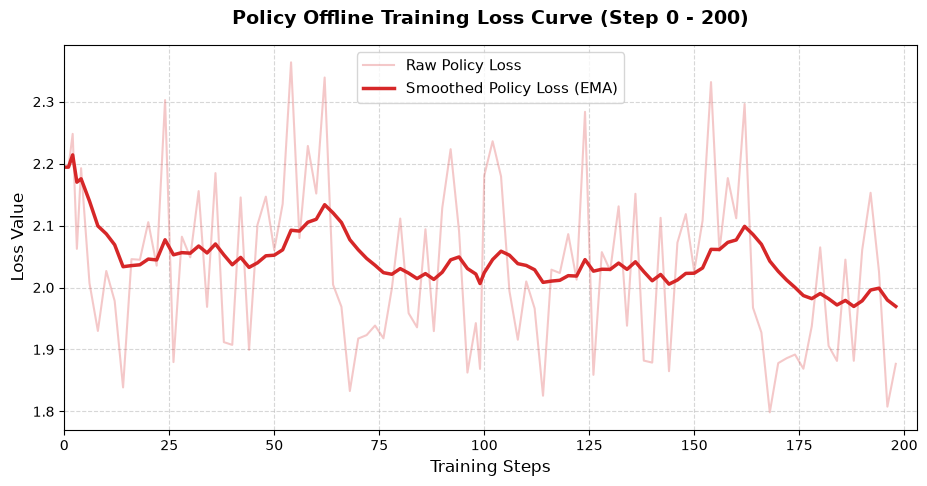

In [1]:
import re
import matplotlib.pyplot as plt
import pandas as pd

# 1. Khai báo đường dẫn đến file output.log của 2 chặng Policy Offline
log_paths = [
    r"C:\TONGHOPTRENLOP\HK6\ML\Project\RISE\policy_and_value\policy_offline_and_value\wandb\offline-run-20260627_115551-qvzp8982\files\output.log",
    r"C:\TONGHOPTRENLOP\HK6\ML\Project\RISE\policy_and_value\policy_offline_and_value\wandb\offline-run-20260627_155732-qvzp8982\files\output.log"
]

data_dict = {}

# 2. Quét trích xuất dữ liệu
for path in log_paths:
    try:
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                match = re.search(r"step=(\d+).*?loss=([0-9.]+)", line) or re.search(r"loss=([0-9.]+).*?step=(\d+)", line)
                if match:
                    if "step=" in match.group(0) and match.group(0).index("step=") < match.group(0).index("loss="):
                        step_val = int(match.group(1))
                        loss_val = float(match.group(2))
                    else:
                        loss_val = float(match.group(1))
                        step_val = int(match.group(2))
                    data_dict[step_val] = loss_val
    except FileNotFoundError:
        print(f"⚠️ Không tìm thấy: {path}")

if not data_dict:
    print("❌ Không trích xuất được dữ liệu loss!")
    exit()

sorted_steps = sorted(data_dict.keys())
sorted_losses = [data_dict[s] for s in sorted_steps]

# 3. Vẽ biểu đồ khoa học cho Policy
plt.figure(figsize=(11, 5))
plt.plot(sorted_steps, sorted_losses, alpha=0.25, color='#d62728', label='Raw Policy Loss')

# Smoothing mượt mà lộ đường cong hội tụ
smoothed_losses = pd.Series(sorted_losses).ewm(alpha=0.1).mean()
plt.plot(sorted_steps, smoothed_losses, color='#d62728', linewidth=2.5, label='Smoothed Policy Loss (EMA)')

plt.title("Policy Offline Training Loss Curve (Step 0 - 200)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Loss Value", fontsize=12)
plt.xlim(0, max(sorted_steps) + 5)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=11)

output_image = "policy_loss_perfect.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"🎉 Biểu đồ Policy đã vẽ xong và lưu tại: {output_image}")
plt.show()

In [2]:
bash vis_value.sh

SyntaxError: invalid syntax (1032502833.py, line 1)

In [3]:
py -3.12 examples/visualize_frame_value_and_advantage.py --policy.config Policy_offline_release --policy.dir checkpoints/Policy_offline_release/policy_local/100 --value.config Value_release --value.dir checkpoints/value_release/value_local/210 --action_horizon 50

SyntaxError: invalid syntax (1100812877.py, line 1)